# Does cost-aware training help when "costs" = margin (|δ|)?
# 
# **Claim:** If we define "costs" as the model's confidence proxy, then training with these costs should not improve classification accuracy over standard training.
# Cost in this case is the margin |δ| from a random linear separator
# 
# **Setup:** 
# - Draw random direction w ~ N(0, I) and normalize.
# - Draw features x ~ N(0, I).
# - Define δ = wᵀx, y = 1{δ ≥ 0}, and weights = |δ|.
# 
# **Methods:**
# 1) Standard logistic regression (unweighted)
# 2) Weighted logistic regression (sample_weight = |δ|)
# 3) Δ-regression (Ridge on δ) + classify by sign(δ̂)
# 
# **Metrics:** Unweighted accuracy and weighted accuracy (weights = |δ| **from the test set**).


In [13]:
# %%
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

seed = 42
rng = np.random.default_rng(seed)

d = 50
n_train = 1_000
n_test  = 10_000

w = rng.normal(size=d)
w = w / np.linalg.norm(w)

Xtr = rng.normal(size=(n_train, d))
Xte = rng.normal(size=(n_test,  d))

delta_tr = Xtr @ w + rng.normal(scale=0.1, size=n_train) # add to gaussian noise
delta_te = Xte @ w + rng.normal(scale=0.1, size=n_test) # add to gaussian noise

y_tr = (delta_tr >= 0).astype(int)
y_te = (delta_te  >= 0).astype(int)

weights_tr = np.abs(delta_tr)
weights_te = np.abs(delta_te)

print("Feature dim d =", d)
print("Train/Test sizes:", Xtr.shape, Xte.shape)
print("|delta| train mean/std:", weights_tr.mean().round(3), weights_tr.std().round(3))


Feature dim d = 50
Train/Test sizes: (1000, 50) (10000, 50)
|delta| train mean/std: 0.793 0.585


# Train models
# 1) Logistic (unweighted)
# 2) Logistic (weighted with |δ|)
# 3) Ridge regression on δ, classify by sign(δ̂)


In [14]:
# %%
# 1) Standard logistic regression
logreg_unw = LogisticRegression(max_iter=1000, solver="lbfgs")
logreg_unw.fit(Xtr, y_tr)
yhat_unw = logreg_unw.predict(Xte)


In [15]:
# %%
# 2) Weighted logistic regression (sample_weight = |δ|)
logreg_w = LogisticRegression(max_iter=1000, solver="lbfgs")
logreg_w.fit(Xtr, y_tr, sample_weight=weights_tr)
yhat_w = logreg_w.predict(Xte)


In [16]:
# %%
# 3) Delta regression (Ridge on δ), then sign(δ̂) for labels
ridge = Ridge(alpha=1.0, random_state=seed)
ridge.fit(Xtr, delta_tr)                  # regress δ
delta_hat = ridge.predict(Xte)
yhat_reg = (delta_hat >= 0).astype(int)   # sign(δ̂)


In [17]:
# 3b) Delta regression (WEIGHTED by |δ|), then sign(δ̂)
ridge_w = Ridge(alpha=1.0, random_state=seed)
ridge_w.fit(Xtr, delta_tr, sample_weight=weights_tr)
delta_hat_w = ridge_w.predict(Xte)
yhat_reg_w = (delta_hat_w >= 0).astype(int)

# ## Metrics: Unweighted & Weighted Accuracy
# Weighted accuracy uses **test** weights |δ| (no leakage).


In [19]:
def weighted_accuracy(y_true, y_pred, weights):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    w = np.asarray(weights, dtype=float)
    return float((w * (y_true == y_pred)).sum() / w.sum())

rows = []
# Logistic (unweighted / |δ|-weighted)
rows.append(("LogReg (unweighted)", "Accuracy", accuracy_score(y_te, yhat_unw)))
rows.append(("LogReg (unweighted)", "Weighted Accuracy", weighted_accuracy(y_te, yhat_unw, weights_te)))
rows.append(("LogReg (|δ| weighted)", "Accuracy", accuracy_score(y_te, yhat_w)))
rows.append(("LogReg (|δ| weighted)", "Weighted Accuracy", weighted_accuracy(y_te, yhat_w, weights_te)))

# Δ-Regression → sign (unweighted / |δ|-weighted)
rows.append(("Δ-Regression (unweighted) → sign", "Accuracy", accuracy_score(y_te, yhat_reg)))
rows.append(("Δ-Regression (unweighted) → sign", "Weighted Accuracy", weighted_accuracy(y_te, yhat_reg, weights_te)))
rows.append(("Δ-Regression (|δ| weighted) → sign", "Accuracy", accuracy_score(y_te, yhat_reg_w)))
rows.append(("Δ-Regression (|δ| weighted) → sign", "Weighted Accuracy", weighted_accuracy(y_te, yhat_reg_w, weights_te)))

results = pd.DataFrame(rows, columns=["Method", "Metric", "Value"])
results_pivot = results.pivot(index="Method", columns="Metric", values="Value").round(4)
results_pivot



Metric,Accuracy,Weighted Accuracy
Method,,
LogReg (unweighted),0.9557,0.9953
LogReg (|δ| weighted),0.9609,0.9961
Δ-Regression (unweighted) → sign,0.9676,0.9974
Δ-Regression (|δ| weighted) → sign,0.9676,0.9974


# ## Sanity check: errors decrease as |δ| grows
# Bin test examples by |δ| (10 quantiles) and plot error rate in each bin.


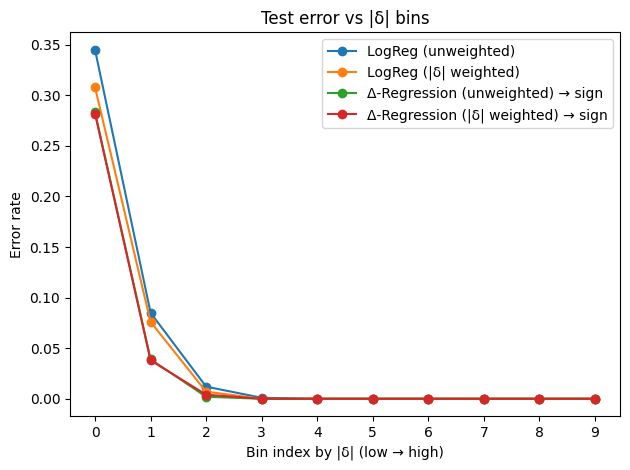

In [21]:
# Compute per-example error (0/1) on test for each method
err_unw = (yhat_unw != y_te).astype(float)
err_w   = (yhat_w   != y_te).astype(float)
err_reg = (yhat_reg != y_te).astype(float)
err_reg_w = (yhat_reg_w != y_te).astype(float)

# Bin by |δ| quantiles
q = np.quantile(weights_te, np.linspace(0, 1, 11))
for i in range(1, len(q)):
    if q[i] <= q[i-1]:
        q[i] = q[i-1] + 1e-12
bins = np.digitize(weights_te, q[1:-1])  # 10 bins labeled 0..9

def binned_mean(v):
    out = []
    for b in range(10):
        m = v[bins == b].mean() if np.any(bins == b) else np.nan
        out.append(m)
    return np.array(out)

err_unw_b   = binned_mean(err_unw)
err_w_b     = binned_mean(err_w)
err_reg_b   = binned_mean(err_reg)
err_reg_w_b = binned_mean(err_reg_w)

plt.figure()
plt.plot(range(10), err_unw_b,   marker="o", label="LogReg (unweighted)")
plt.plot(range(10), err_w_b,     marker="o", label="LogReg (|δ| weighted)")
plt.plot(range(10), err_reg_b,   marker="o", label="Δ-Regression (unweighted) → sign")
plt.plot(range(10), err_reg_w_b, marker="o", label="Δ-Regression (|δ| weighted) → sign")
plt.xticks(range(10))
plt.xlabel("Bin index by |δ| (low → high)")
plt.ylabel("Error rate")
plt.title("Test error vs |δ| bins")
plt.legend()
plt.tight_layout()
plt.show()



# ## Correlation: |δ| vs mistakes should be negative
# Larger margins → fewer mistakes.


In [26]:
# %%
mist_unw = (yhat_unw != y_te).astype(float)
corr = np.corrcoef(weights_te, mist_unw)[0, 1]
print("corr(|δ|, mistake) =", round(float(corr), 4))


corr(|δ|, mistake) = -0.2582


# %% [markdown]
# ## Inspect δ distribution
# A quick look at signed δ; should be symmetric around 0 under this synthetic.


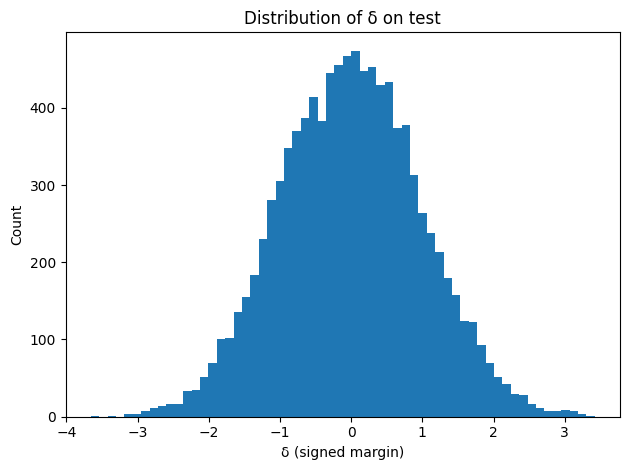

In [27]:
# %%
plt.figure()
plt.hist(delta_te, bins=60)
plt.xlabel("δ (signed margin)")
plt.ylabel("Count")
plt.title("Distribution of δ on test")
plt.tight_layout()
plt.show()
